In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(0)

sns.set_theme(style='darkgrid')
plt.rcParams["font.family"] = 'arial'
plt.rcParams['text.usetex'] = True

MARKERS = {
    'Baseline': 'X',
    'RobX': 'o',
    'BetaRobust': 's',
    'DiRARTE-W': '^',
    'DiRARTE-X': 'v'
}
COLORS = {
    'Baseline': 'tab:gray',
    'RobX': 'tab:blue',
    'BetaRobust': 'tab:orange',
    'DiRARTE-W': 'tab:green',
    'DiRARTE-X': 'tab:red'
}

## Main Paper

In [2]:
def line_plot(results, aspect_ratio=(3, 3), feasibility_threshold=0.9, errorbar=False):

    methods = results['method'].unique()
    datasets = results['dataset'].unique()
    shift_types = results['shift_type'].unique()

    fig = plt.figure(figsize=(len(datasets) * aspect_ratio[0], len(shift_types) * aspect_ratio[1]))    
    for i, shift_type in enumerate(shift_types):
        for j, dataset in enumerate(datasets):

            ax = plt.subplot(len(shift_types), len(datasets), i*len(datasets) + j + 1)
            result = results[(results['dataset'] == dataset) & (results['shift_type'] == shift_type)]

            for k, method in enumerate(methods):
                result_method = result[(result['method'] == method)].groupby('parameter')
                is_feasible = (result_method['validity (before)'].mean() > feasibility_threshold)
                y_mean = result_method['validity (after)'].mean()[is_feasible]
                y_std = result_method['validity (after)'].std()[is_feasible]
                x_mean = result_method['cost'].mean()[is_feasible]
                x_std = result_method['cost'].std()[is_feasible]

                label_name = method
                if method == 'DiRARTE-W': label_name = r'DiRARTE-$W$'
                elif method == 'DiRARTE-X': label_name = r'DiRARTE-$\chi^2$'

                if method == 'Baseline':
                    sns.scatterplot(x=x_mean, y=y_mean, label=label_name, marker=MARKERS[method], color=COLORS[method], s=80)
                else:
                    sns.lineplot(x=x_mean, y=y_mean, label=label_name, marker=MARKERS[method], color=COLORS[method], 
                                 markersize=11, linestyle='dashed', alpha=0.7)
                    if errorbar:
                        plt.errorbar(x=x_mean, y=y_mean, xerr=x_std, yerr=y_std, color=COLORS[method], alpha=0.3, capsize=5)

            ax.get_legend().remove() if ax.get_legend() else None            
            plt.xlabel(r'Average Cost $(\downarrow)$')
            plt.ylabel(r'Robust Validity $(\uparrow)$')
            shift_map = {'split': 'DataSplit', 'delete': 'DataDeletion', 'label': 'LabelShift'}
            shift_type_label = shift_map.get(shift_type, shift_type)
            plt.title('{} - {}'.format(dataset, shift_type_label))

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles, 
        labels, 
        loc='lower center',
        bbox_to_anchor=(0.5, 0.05), 
        ncol=len(methods), 
        fontsize=10,
        frameon=True
    )
    plt.tight_layout(rect=[0, 0.1, 1, 1])    


def bar_plot(results, key='time per samples', shift_type=None, aspect_ratio=(3, 3), feasibility_threshold=0.9):
    
    methods = results['method'].unique()
    datasets = results['dataset'].unique()
    if shift_type is not None:
        results = results[results['shift_type'] == shift_type]
    if feasibility_threshold > 0.0:
        results = results[results['validity (before)'] > feasibility_threshold]
    key_label = 'Time [s]' if key == 'time per samples' else key.title()

    fig = plt.figure(figsize=(len(datasets) * aspect_ratio[0], aspect_ratio[1]))
    handles, labels = [], []
    for i, dataset in enumerate(datasets):
        ax = plt.subplot(1, len(datasets), i + 1)
        results_subset = results[results['dataset'] == dataset]
        sns.barplot(x='method', y=key, data=results_subset, palette=COLORS, hue='method', legend=True, errorbar='sd', ax=ax)

        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
        if ax.get_legend():
            ax.get_legend().remove()
        plt.xlabel('')
        plt.ylabel(key_label)
        plt.xticks([])
        plt.title(dataset)
    
    labels = [label.replace('DiRARTE-W', r'DiRARTE-$W$').replace('DiRARTE-X', r'DiRARTE-$\chi^2$') for label in labels]
    fig.legend(
        handles, 
        labels, 
        loc='lower center',
        bbox_to_anchor=(0.5, 0.01), 
        ncol=len(methods), 
        fontsize=10,
        frameon=True
    )
    plt.tight_layout(rect=[0, 0.1, 1, 1])    

                

def latex_table(results, keys=['sparsity', 'plausibility', 'time per samples'], shift_type=None, feasibility_threshold=0.9, round_mean=3, round_std=2):
        
    methods = results['method'].unique()
    datasets = results['dataset'].unique()
    if shift_type is not None:
        results = results[results['shift_type'] == shift_type]

    for key in keys:
        key_label = 'Time [s]' if key == 'time per samples' else key.title()
        print('\\midrule')
        print('\\multirow{' + str(len(methods)) + '}{*}{\\rotatebox{90}{' + key_label + '}}')
        for method in methods:
            if method == 'DiRARTE-W':
                method_label = r'DiRARTE-$W$'
            elif method == 'DiRARTE-X':
                method_label = r'DiRARTE-$\chi^2$'
            else:
                method_label = method
            line = '& {}'.format(method_label)
            for dataset in datasets:
                result_method = results[(results['method'] == method) & (results['dataset'] == dataset)]
                if feasibility_threshold > 0.0:
                    result_method = result_method[result_method['validity (before)'] > feasibility_threshold]
                line += ' & ${} \pm {}$'.format(result_method[key].mean().round(round_mean), result_method[key].std().round(round_std))
            line += ' \\\\'
            print(line)


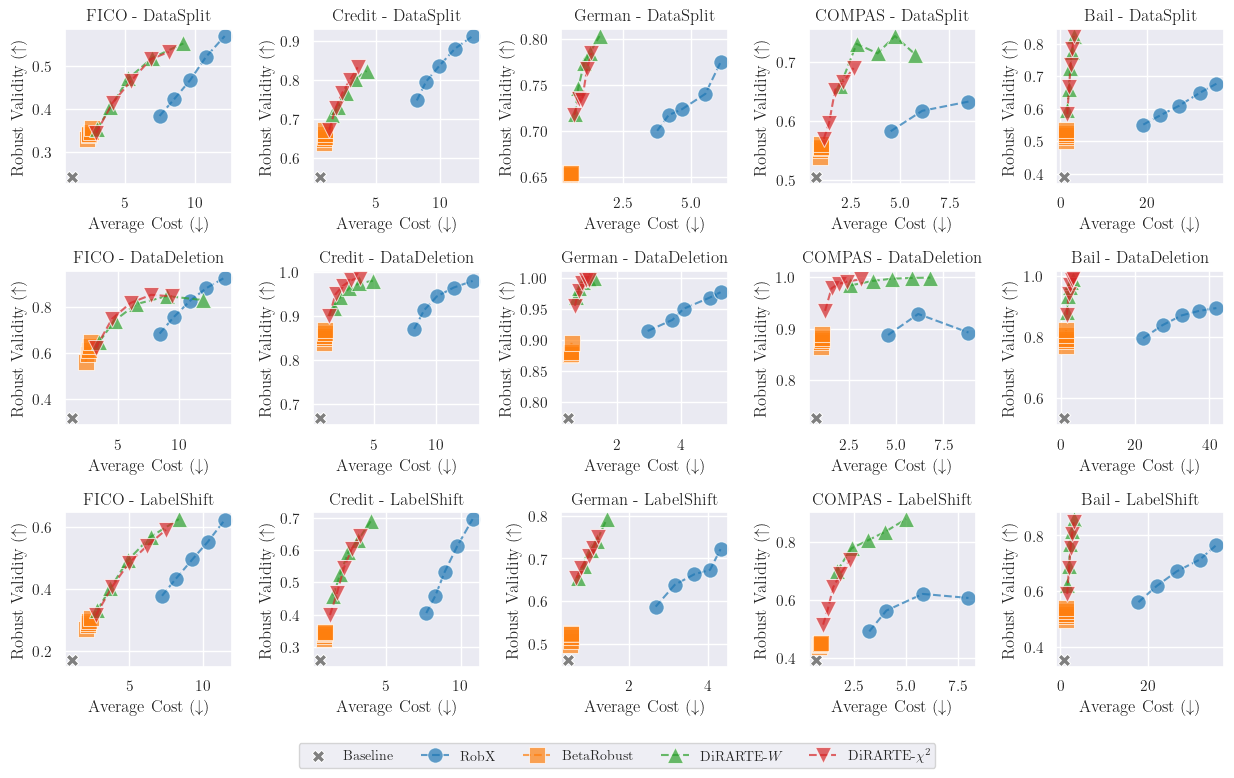

In [3]:
results = pd.read_csv('./results/results_comparison.csv')
results_xg_tlps = results[(results['estimator'] == 'XGBoost') & (results['cost_type'] == 'tlps')]
line_plot(results_xg_tlps, aspect_ratio=(2.5, 2.75))
plt.savefig('./figures/01_comparison.pdf', bbox_inches='tight', pad_inches=0.05)

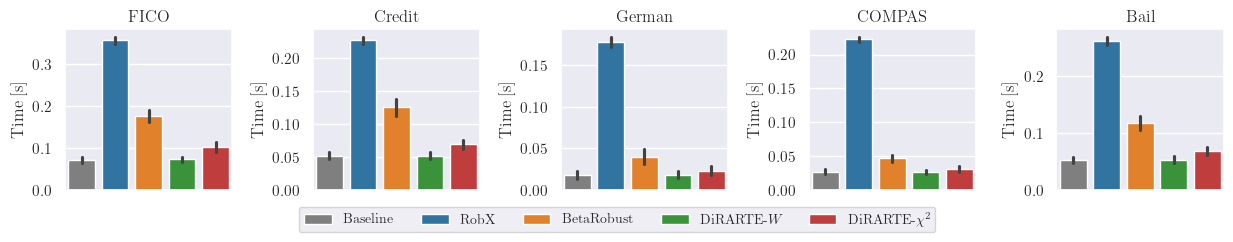

In [4]:
bar_plot(results_xg_tlps, key='time per samples', aspect_ratio=(2.5, 2.5))
plt.savefig('./figures/01_comparison_time.pdf', bbox_inches='tight', pad_inches=0.05)

In [5]:
latex_table(results_xg_tlps, keys=['sparsity', 'plausibility'])

\midrule
\multirow{5}{*}{\rotatebox{90}{Sparsity}}
& Baseline & $1.779 \pm 0.05$ & $1.122 \pm 0.04$ & $1.049 \pm 0.03$ & $1.118 \pm 0.03$ & $1.33 \pm 0.03$ \\
& RobX & $15.195 \pm 0.13$ & $6.527 \pm 0.26$ & $3.859 \pm 0.18$ & $2.238 \pm 0.23$ & $5.574 \pm 0.4$ \\
& BetaRobust & $2.398 \pm 0.11$ & $1.247 \pm 0.07$ & $1.09 \pm 0.05$ & $1.209 \pm 0.04$ & $1.508 \pm 0.04$ \\
& DiRARTE-$W$ & $3.536 \pm 0.55$ & $2.176 \pm 0.4$ & $1.434 \pm 0.21$ & $1.678 \pm 0.12$ & $1.976 \pm 0.19$ \\
& DiRARTE-$\chi^2$ & $3.485 \pm 0.53$ & $1.962 \pm 0.34$ & $1.392 \pm 0.18$ & $1.46 \pm 0.15$ & $2.002 \pm 0.22$ \\
\midrule
\multirow{5}{*}{\rotatebox{90}{Plausibility}}
& Baseline & $0.453 \pm 0.0$ & $0.509 \pm 0.01$ & $0.499 \pm 0.01$ & $0.452 \pm 0.0$ & $0.494 \pm 0.0$ \\
& RobX & $0.438 \pm 0.0$ & $0.482 \pm 0.01$ & $0.495 \pm 0.01$ & $0.447 \pm 0.01$ & $0.497 \pm 0.01$ \\
& BetaRobust & $0.452 \pm 0.01$ & $0.512 \pm 0.01$ & $0.499 \pm 0.01$ & $0.451 \pm 0.01$ & $0.496 \pm 0.0$ \\
& DiRARTE-$W$ & $0.458 \

## Appendix

### Complete results on the baseline comparison

Cost type: tlps, Estimator: XGBoost
Cost type: tlps, Estimator: RandomForest
Cost type: std, Estimator: XGBoost
Cost type: std, Estimator: RandomForest


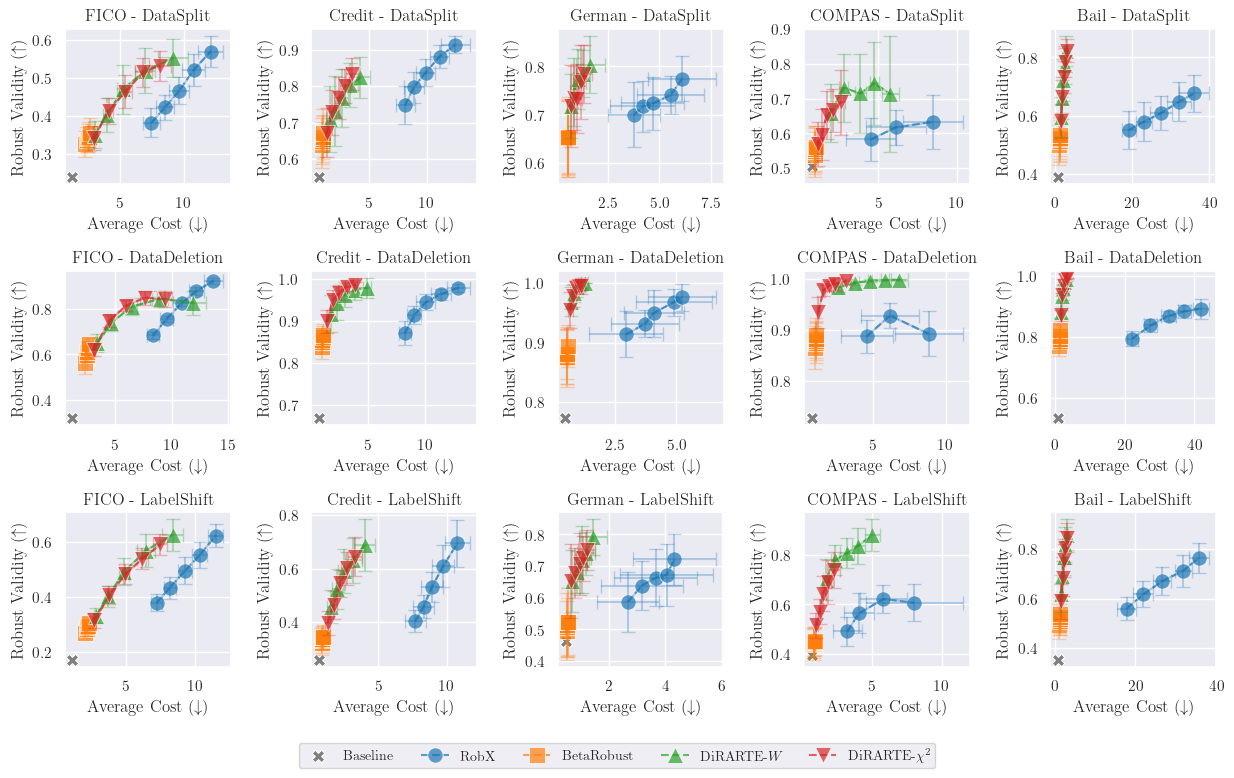

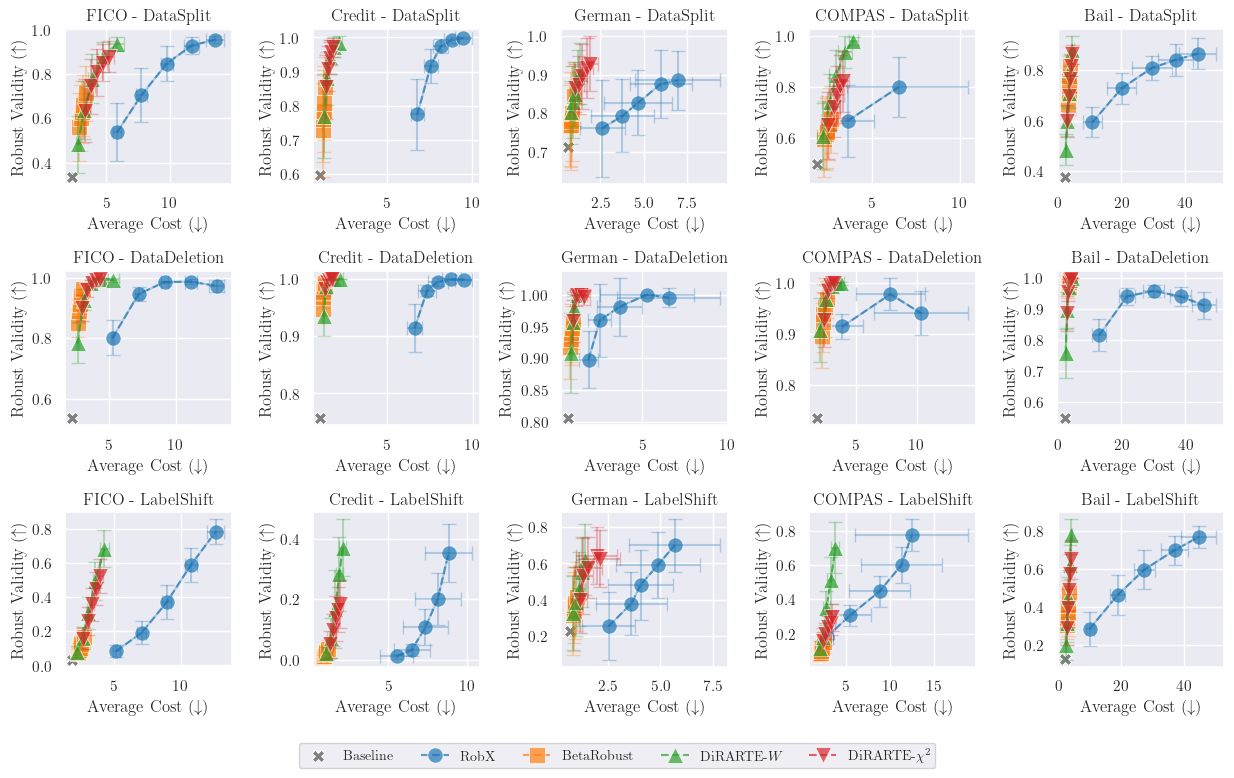

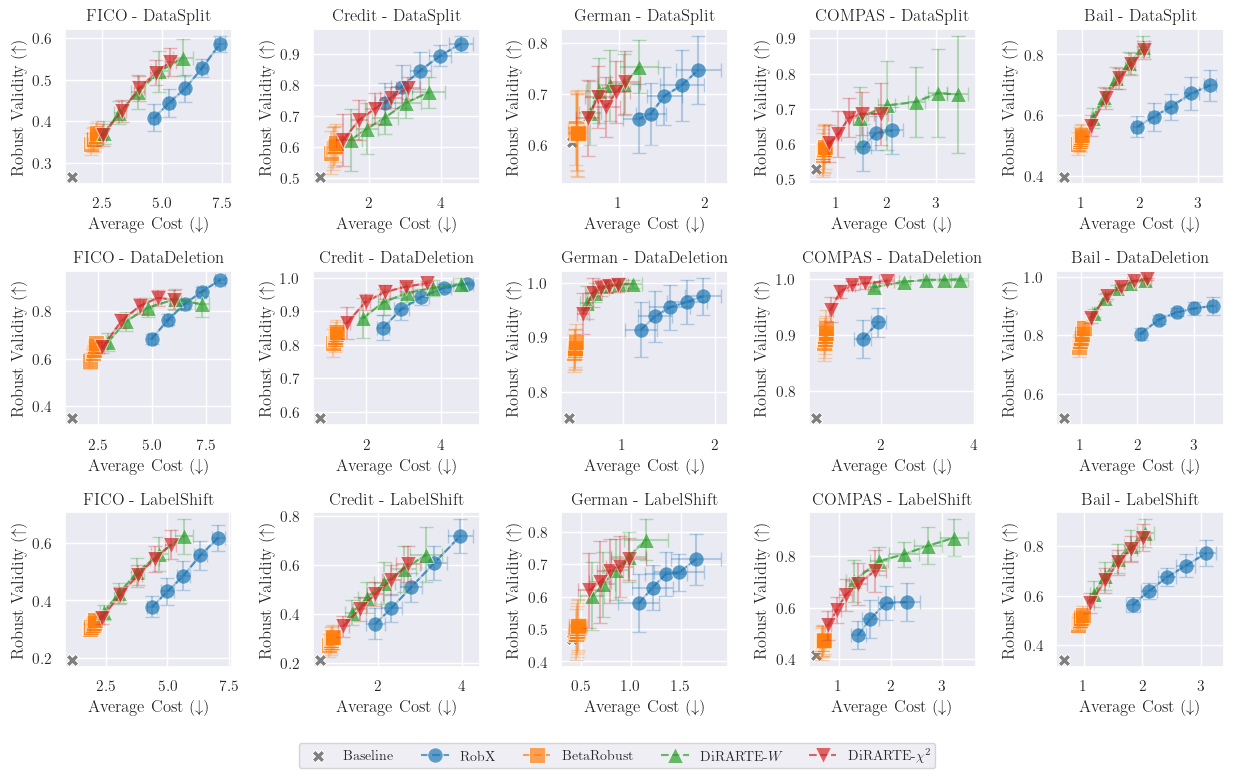

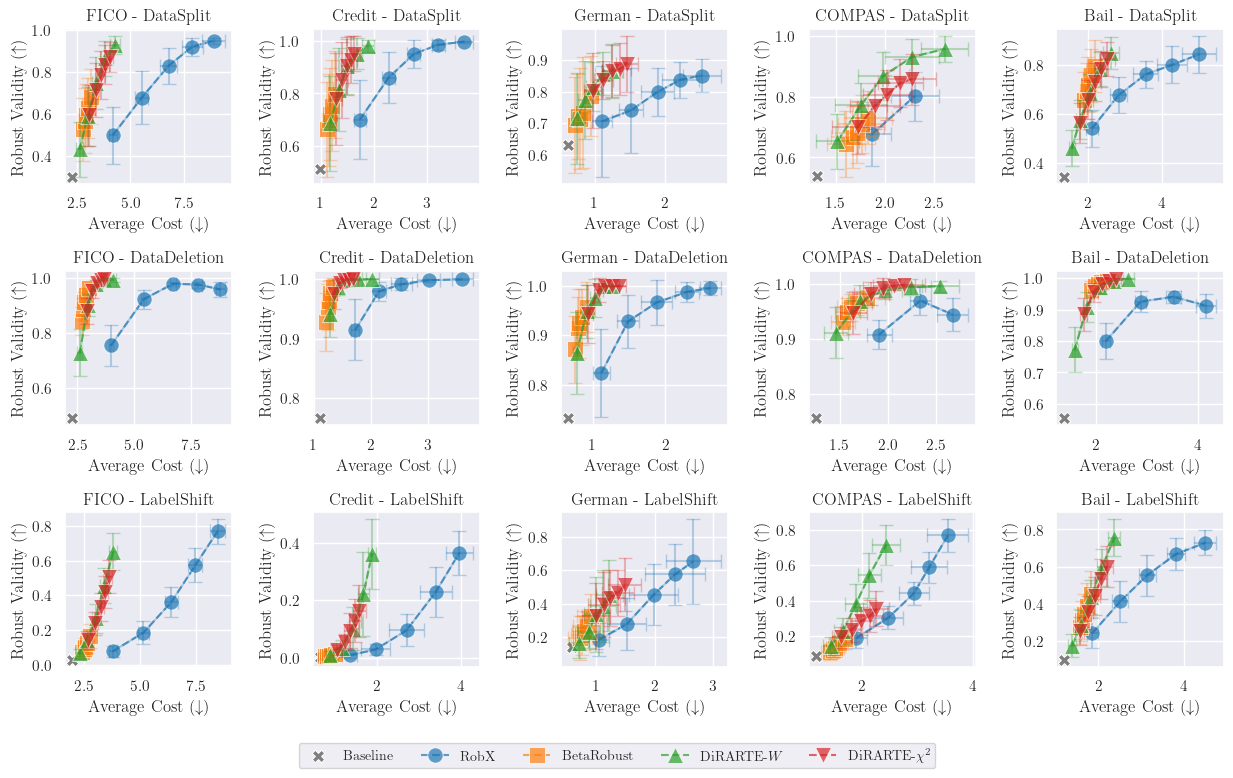

In [6]:
results = pd.read_csv('./results/results_comparison.csv')
for cost_type in ['tlps', 'std']:
    for estimator in ['XGBoost', 'RandomForest']:
        results_subset = results[(results['estimator'] == estimator) & (results['cost_type'] == cost_type)]
        print('Cost type: {}, Estimator: {}'.format(cost_type, estimator))
        line_plot(results_subset, aspect_ratio=(2.5, 2.75), errorbar=True)
        plt.savefig('./figures/02_comparison_{}_{}.pdf'.format('xg' if estimator == 'XGBoost' else 'rf', cost_type), bbox_inches='tight', pad_inches=0.05)


In [7]:
results = pd.read_csv('./results/results_comparison.csv')
for cost_type in ['tlps', 'std']:
    for estimator in ['XGBoost', 'RandomForest']:
        results_subset = results[(results['estimator'] == estimator) & (results['cost_type'] == cost_type)]
        print('Cost type: {}, Estimator: {}'.format(cost_type, estimator))
        latex_table(results_subset)
        print()

Cost type: tlps, Estimator: XGBoost
\midrule
\multirow{5}{*}{\rotatebox{90}{Sparsity}}
& Baseline & $1.779 \pm 0.05$ & $1.122 \pm 0.04$ & $1.049 \pm 0.03$ & $1.118 \pm 0.03$ & $1.33 \pm 0.03$ \\
& RobX & $15.195 \pm 0.13$ & $6.527 \pm 0.26$ & $3.859 \pm 0.18$ & $2.238 \pm 0.23$ & $5.574 \pm 0.4$ \\
& BetaRobust & $2.398 \pm 0.11$ & $1.247 \pm 0.07$ & $1.09 \pm 0.05$ & $1.209 \pm 0.04$ & $1.508 \pm 0.04$ \\
& DiRARTE-$W$ & $3.536 \pm 0.55$ & $2.176 \pm 0.4$ & $1.434 \pm 0.21$ & $1.678 \pm 0.12$ & $1.976 \pm 0.19$ \\
& DiRARTE-$\chi^2$ & $3.485 \pm 0.53$ & $1.962 \pm 0.34$ & $1.392 \pm 0.18$ & $1.46 \pm 0.15$ & $2.002 \pm 0.22$ \\
\midrule
\multirow{5}{*}{\rotatebox{90}{Plausibility}}
& Baseline & $0.453 \pm 0.0$ & $0.509 \pm 0.01$ & $0.499 \pm 0.01$ & $0.452 \pm 0.0$ & $0.494 \pm 0.0$ \\
& RobX & $0.438 \pm 0.0$ & $0.482 \pm 0.01$ & $0.495 \pm 0.01$ & $0.447 \pm 0.01$ & $0.497 \pm 0.01$ \\
& BetaRobust & $0.452 \pm 0.01$ & $0.512 \pm 0.01$ & $0.499 \pm 0.01$ & $0.451 \pm 0.01$ & $0.496 

### Ablation study on FT++ algorithm

In [8]:
def plot_merge_level(results, aspect_ratio=(3, 3)):

    datasets = results['dataset'].unique()
    methods = ['DiRARTE-W', 'DiRARTE-X']

    fig = plt.figure(figsize=(len(datasets) * aspect_ratio[0], len(methods) * aspect_ratio[1]))
    for i, method in enumerate(methods):
        for j, dataset in enumerate(datasets):
            plt.subplot(len(methods), len(datasets), i*len(datasets) + j + 1)
            results_method = results[(results['dataset'] == dataset) & (results['method'] == method)]
            epsilons = results_method['parameter'].unique()
            
            for merge_level in [1, 2]:
                result_method = results_method[(results_method['merge_level'] == merge_level)].groupby('parameter')
                validity_mean = result_method['validity (before)'].mean()
                validity_std = result_method['validity (before)'].std()
                if method == 'DiRARTE-W':
                    sns.lineplot(x=epsilons, y=validity_mean, label=r'$L={}$'.format(merge_level), 
                                    marker='o', color='tab:blue' if merge_level == 1 else 'tab:orange', markersize=10, linestyle='dashed', alpha=0.7)
                    plt.fill_between(x=epsilons, y1=validity_mean-validity_std, y2=validity_mean+validity_std, color='tab:blue' if merge_level == 1 else 'tab:orange', alpha=0.2)
                elif method == 'DiRARTE-X':
                    sns.lineplot(x=epsilons, y=validity_mean, label=r'$L={}$'.format(merge_level), 
                                    marker='s', color='tab:blue' if merge_level == 1 else 'tab:orange', markersize=10, linestyle='dashed', alpha=0.7)
                    plt.fill_between(x=epsilons, y1=validity_mean-validity_std, y2=validity_mean+validity_std, color='tab:blue' if merge_level == 1 else 'tab:orange', alpha=0.2)

                plt.legend(fontsize=9, loc='lower left')
                plt.xlabel(r'Radius $\varepsilon$')
                plt.ylabel(r'Validity')
                plt.title('{} - {}'.format(dataset, r'DiRARTE-$W$' if method == 'DiRARTE-W' else r'DiRARTE-$\chi^2$'))

    plt.tight_layout()
    
    
def plot_prune_level(results, aspect_ratio=(3, 3), feasibility_threshold=0.9, errorbar=True):

    datasets = results['dataset'].unique()
    shift_types = results['shift_type'].unique()
    results = results[results['merge_level'] == 2]

    fig = plt.figure(figsize=(len(datasets) * aspect_ratio[0], len(shift_types) * aspect_ratio[1]))
    for i, shift_type in enumerate(shift_types):
        for j, dataset in enumerate(datasets):

            ax = plt.subplot(len(shift_types), len(datasets), i*len(datasets) + j + 1)
            result = results[(results['dataset'] == dataset) & (results['shift_type'] == shift_type)]

            for k, method in enumerate(['DiRARTE-W', 'DiRARTE-X']):
                for prune_level in [1.0, 0.5]:
                    result_method = result[(result['method'] == method) & (result['prune_level'] == prune_level)].groupby('parameter')
                    is_feasible = (result_method['validity (before)'].mean() > feasibility_threshold)
                    y_mean = result_method['validity (after)'].mean()[is_feasible]
                    y_std = result_method['validity (after)'].std()[is_feasible]
                    x_mean = result_method['cost'].mean()[is_feasible]
                    x_std = result_method['cost'].std()[is_feasible]
                    if method == 'DiRARTE-W':
                        sns.lineplot(x=x_mean, y=y_mean, 
                                     label=r'DiRARTE-$W$' if prune_level == 1.0 else r'DiRARTE-$W$ (pruned)', 
                                     marker='o' if prune_level == 1.0 else 's', color='tab:olive' if prune_level == 1.0 else 'tab:green', 
                                     markersize=10, linestyle='dashed', alpha=0.7)
                        if errorbar:
                            plt.errorbar(x=x_mean, y=y_mean, xerr=x_std, yerr=y_std, color='tab:olive' if prune_level == 1.0 else 'tab:green', alpha=0.3, capsize=5)
                    elif method == 'DiRARTE-X':
                        sns.lineplot(x=x_mean, y=y_mean, 
                                     label=r'DiRARTE-$\chi^2$' if prune_level == 1.0 else r'DiRARTE-$\chi^2$ (pruned)', 
                                     marker='^' if prune_level == 1.0 else 'v', color='tab:pink' if prune_level == 1.0 else 'tab:red', 
                                     markersize=10, linestyle='dashed', alpha=0.7)
                        if errorbar:
                            plt.errorbar(x=x_mean, y=y_mean, xerr=x_std, yerr=y_std, color='tab:pink' if prune_level == 1.0 else 'tab:red', alpha=0.3, capsize=5)

            ax.get_legend().remove() if ax.get_legend() else None            
            plt.xlabel(r'Average Cost $(\downarrow)$')
            plt.ylabel(r'Robust Validity $(\uparrow)$')
            if shift_type == 'split':
                shift_type_label = 'DataSplit'
            elif shift_type == 'delete':
                shift_type_label = 'DataDeletion'
            elif shift_type == 'label':
                shift_type_label = 'LabelShift'
            plt.title('{} - {}'.format(dataset, shift_type_label))

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles, 
        labels, 
        loc='lower center',
        bbox_to_anchor=(0.5, 0.05), 
        ncol=4, 
        fontsize=10,
        frameon=True
    )
    plt.tight_layout(rect=[0, 0.1, 1, 1])       


def table_prune_level(results, key='time per samples', shift_type=None, feasibility_threshold=0.9, round_mean=3, round_std=2):
        
    datasets = results['dataset'].unique()
    results = results[results['merge_level'] == 2]
    if shift_type is not None:
        results = results[results['shift_type'] == shift_type]

    for method in ['DiRARTE-W', 'DiRARTE-X']:

        if method == 'DiRARTE-W':
            method_label = r'$W$'
        elif method == 'DiRARTE-X':
            method_label = r'$\chi^2$'
        print('\\midrule')
        print('\\multirow{' + '3' + '}{*}{' + method_label + '}')
            
        line = '& no pruning'.format(method_label)
        before = []
        for dataset in datasets:
            result_method = results[(results['method'] == method) & (results['dataset'] == dataset) & (results['prune_level'] == 1.0)]
            if feasibility_threshold > 0.0:
                result_method = result_method[result_method['validity (before)'] > feasibility_threshold]
            line += ' & ${} \pm {}$'.format(result_method[key].mean().round(round_mean), result_method[key].std().round(round_std))
            before.append(result_method[key].mean())
        line += ' \\\\'
        print(line)
        
        line = '& 50\% pruning'
        after = []
        for dataset in datasets:
            result_method = results[(results['method'] == method) & (results['dataset'] == dataset) & (results['prune_level'] == 0.5)]
            if feasibility_threshold > 0.0:
                result_method = result_method[result_method['validity (before)'] > feasibility_threshold]
            line += ' & ${} \pm {}$'.format(result_method[key].mean().round(round_mean), result_method[key].std().round(round_std))
            after.append(result_method[key].mean())
        line += ' \\\\'
        print(line)
        
        line = '& relative change'
        for b, a in zip(before, after):
            relative_change = (a - b) / b if b != 0 else 0.0
            line += ' & ${} \%$'.format((relative_change * 100).round(2))
        line += ' \\\\'
        print(line)
        


Cost type: tlps, Estimator: XGBoost
Cost type: tlps, Estimator: RandomForest
Cost type: std, Estimator: XGBoost
Cost type: std, Estimator: RandomForest


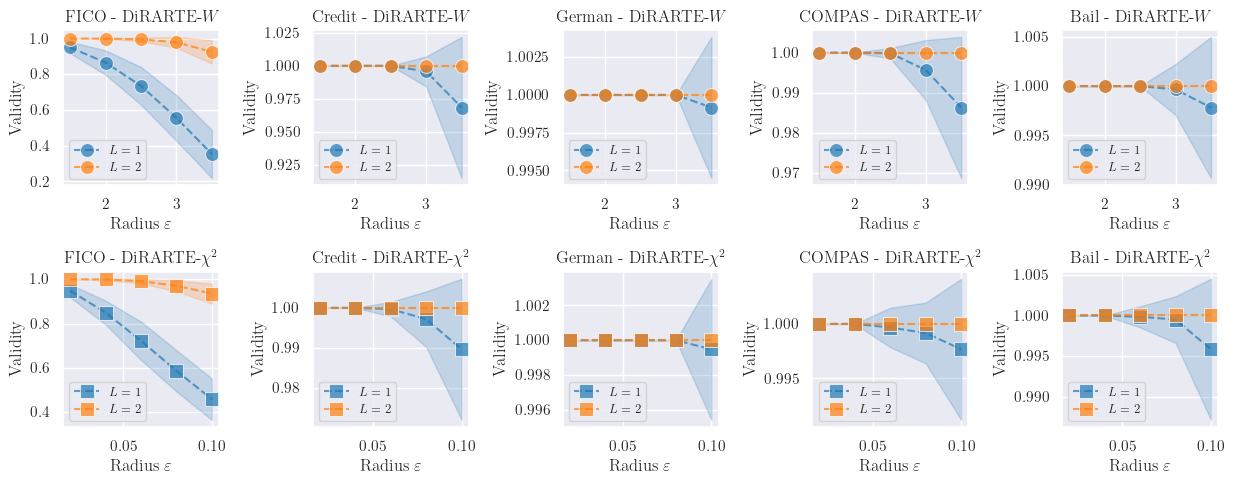

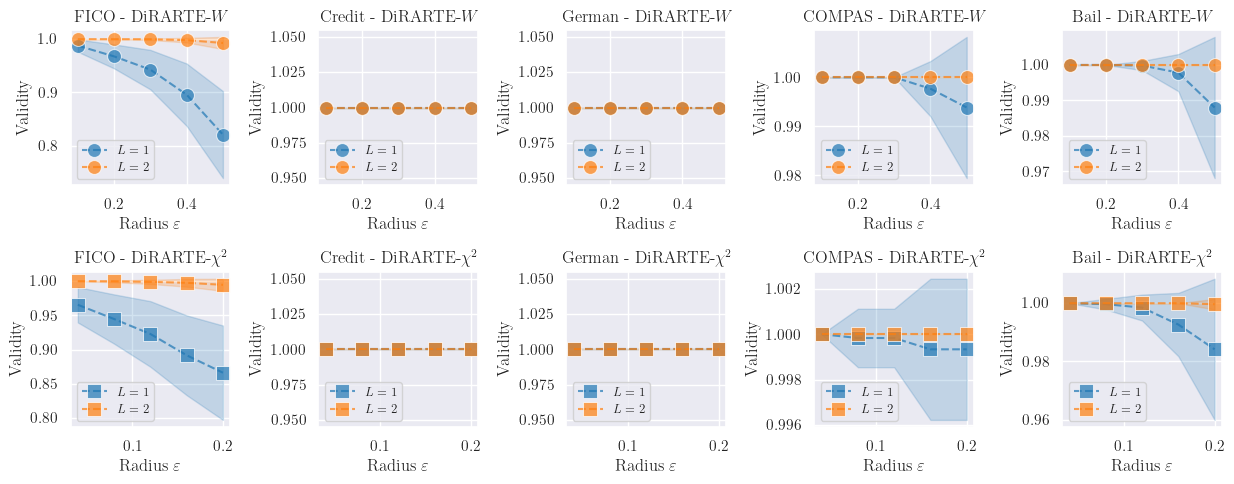

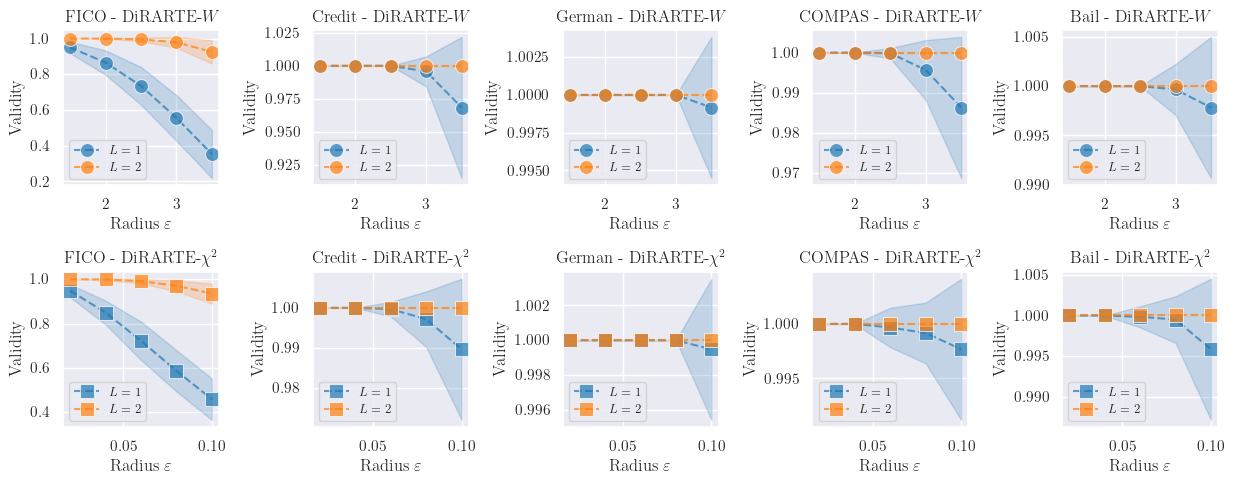

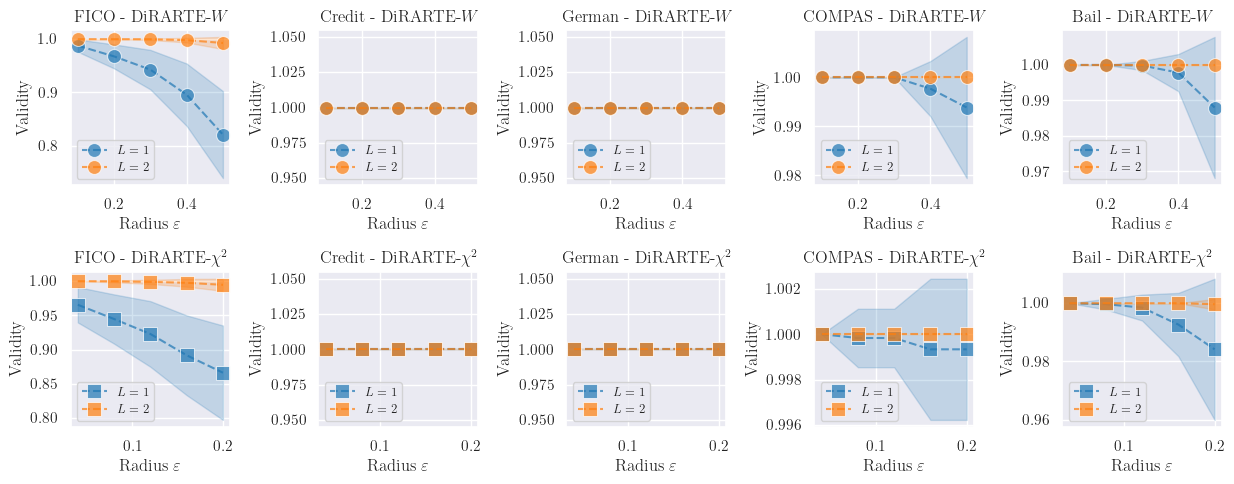

In [9]:
results = pd.read_csv('./results/results_ablation.csv')
for cost_type in ['tlps', 'std']:
    for estimator in ['XGBoost', 'RandomForest']:
        results_subset = results[(results['estimator'] == estimator) & (results['cost_type'] == cost_type)]
        print('Cost type: {}, Estimator: {}'.format(cost_type, estimator))
        plot_merge_level(results_subset, aspect_ratio=(2.5, 2.5))
        plt.savefig('./figures/03_ablation_merge_{}_{}.pdf'.format('xg' if estimator == 'XGBoost' else 'rf', cost_type), bbox_inches='tight', pad_inches=0.05)

Cost type: tlps, Estimator: XGBoost
Cost type: tlps, Estimator: RandomForest
Cost type: std, Estimator: XGBoost
Cost type: std, Estimator: RandomForest


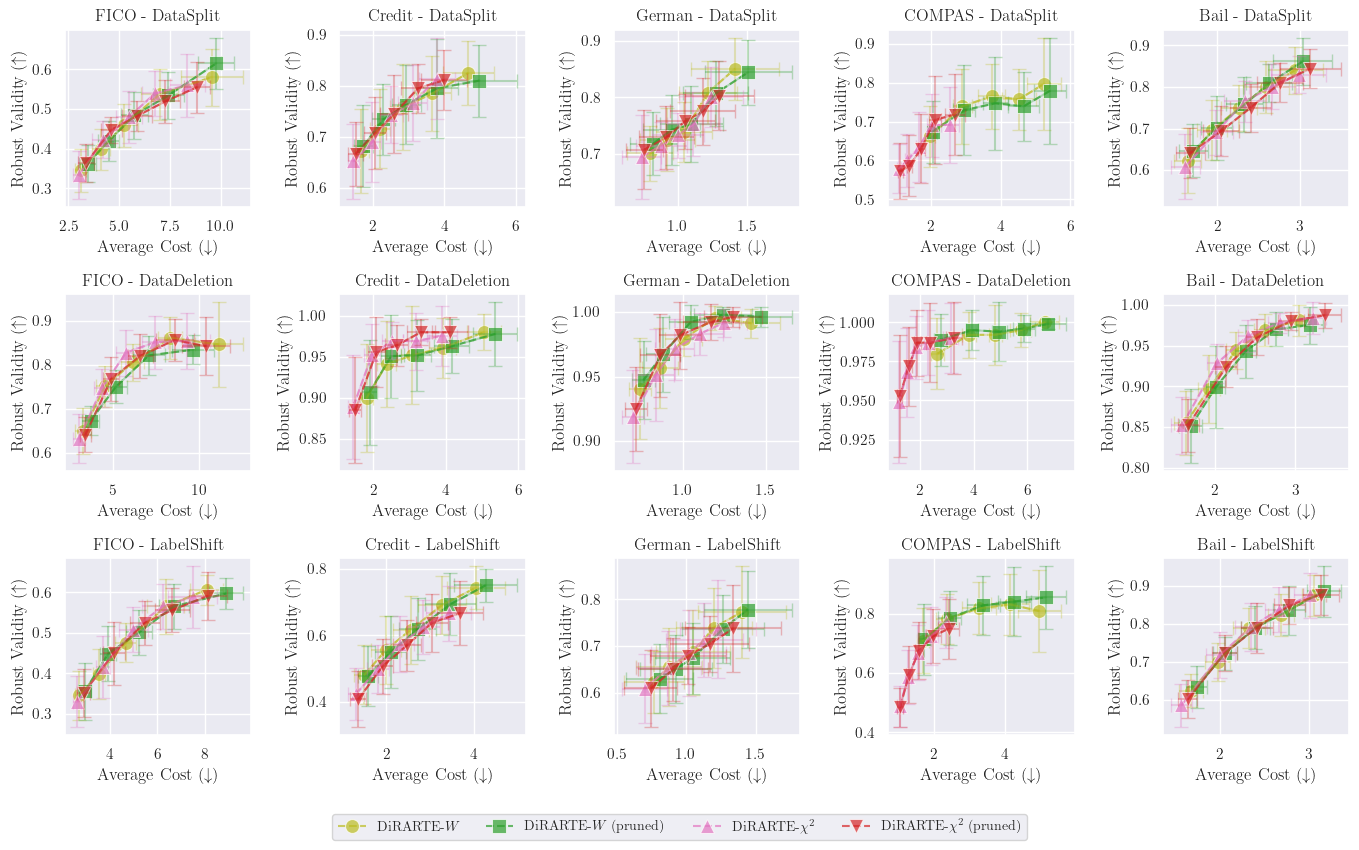

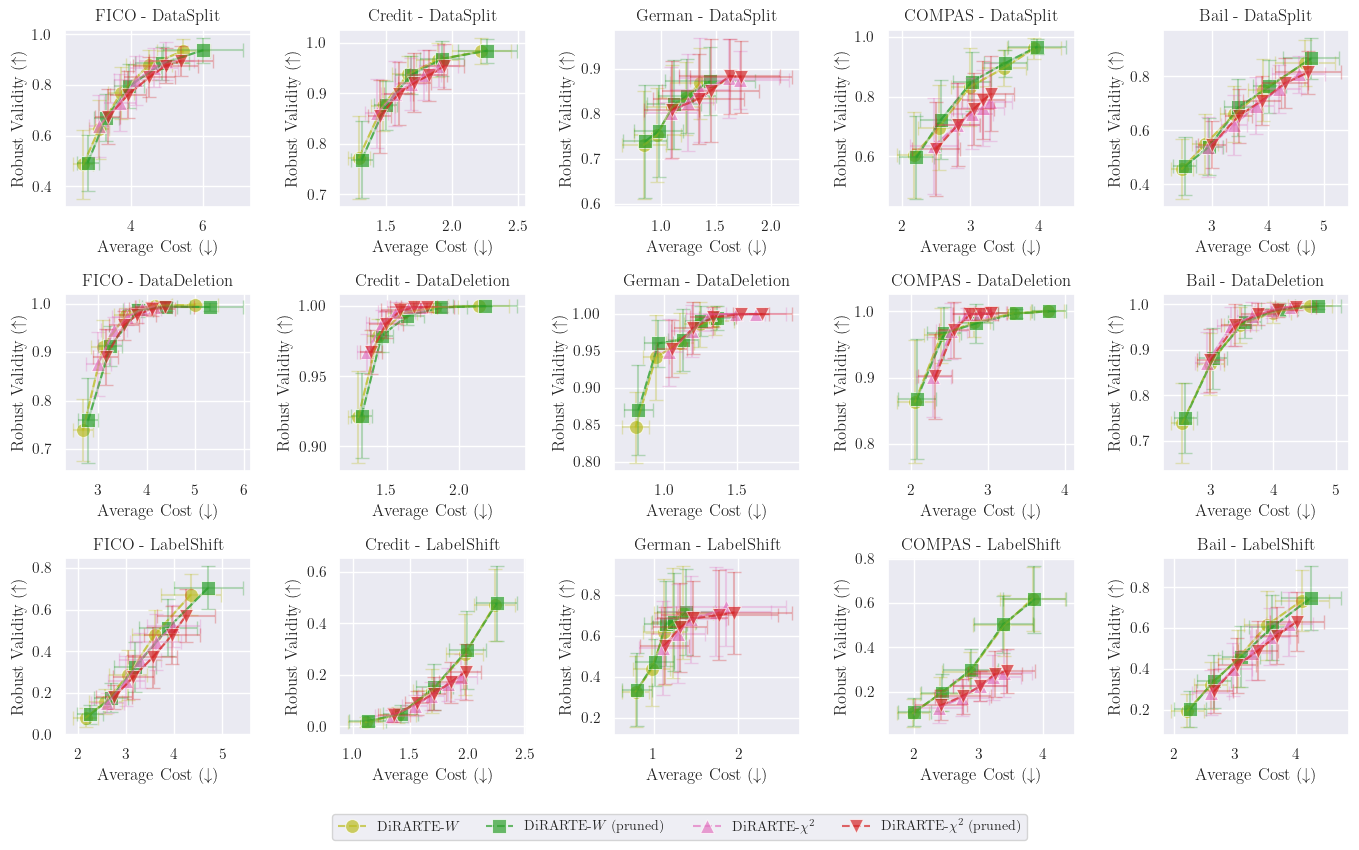

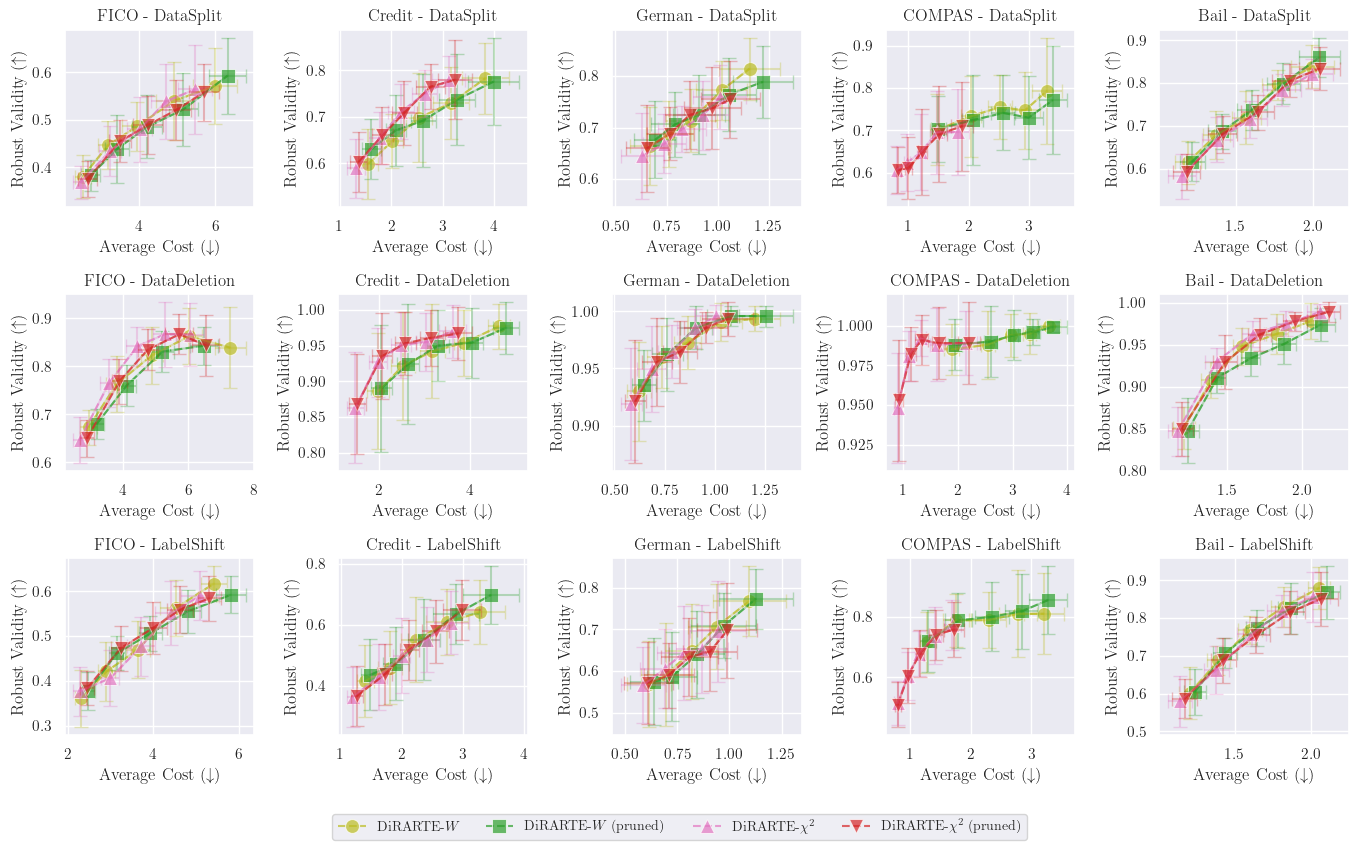

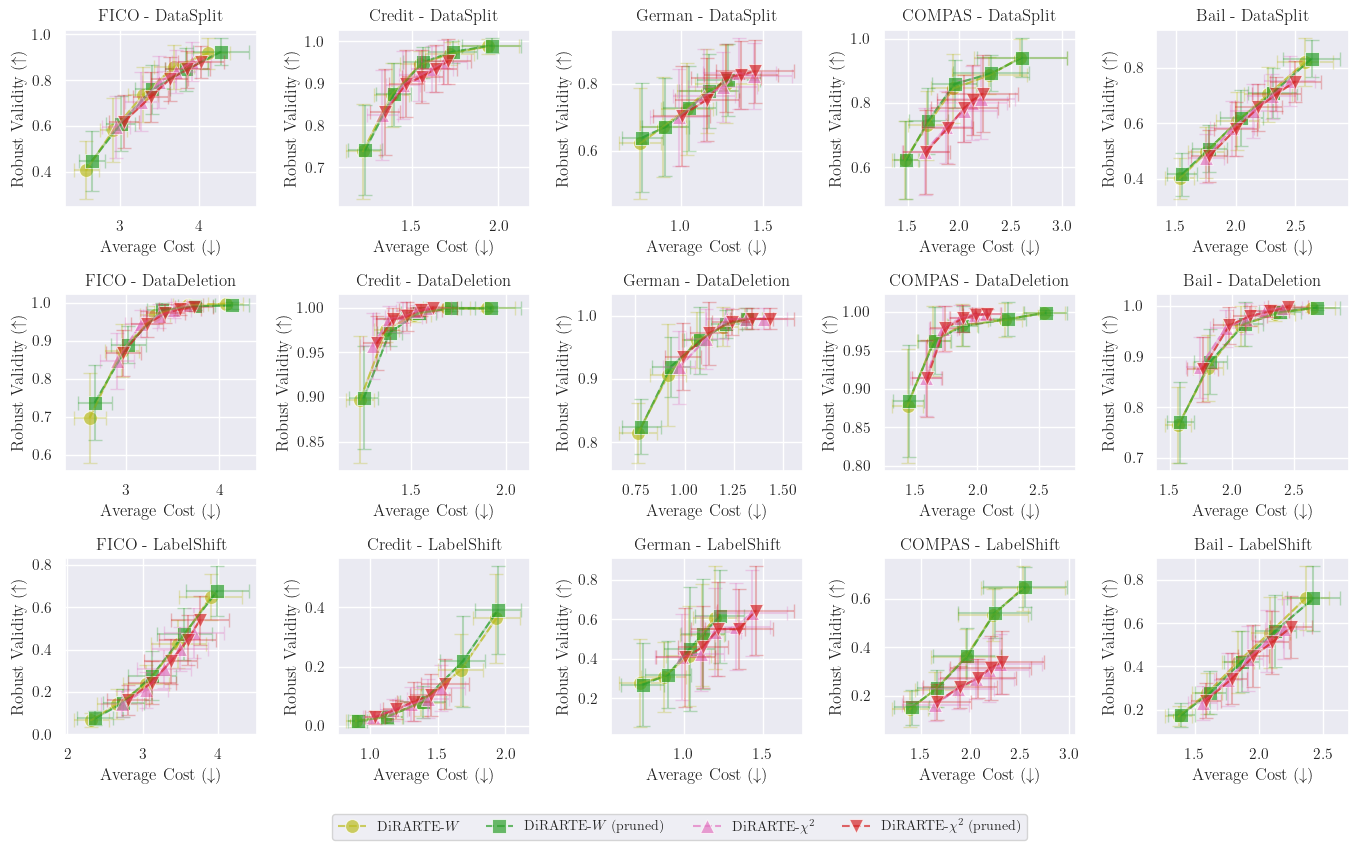

In [10]:
results = pd.read_csv('./results/results_ablation.csv')
for cost_type in ['tlps', 'std']:
    for estimator in ['XGBoost', 'RandomForest']:
        results_subset = results[(results['estimator'] == estimator) & (results['cost_type'] == cost_type)]
        print('Cost type: {}, Estimator: {}'.format(cost_type, estimator))
        plot_prune_level(results_subset, aspect_ratio=(2.75, 3))
        plt.savefig('./figures/03_ablation_prune_{}_{}.pdf'.format('xg' if estimator == 'XGBoost' else 'rf', cost_type), bbox_inches='tight', pad_inches=0.05)
        

In [11]:
for cost_type in ['tlps', 'std']:
    for estimator in ['XGBoost', 'RandomForest']:
        results_subset = results[(results['estimator'] == estimator) & (results['cost_type'] == cost_type)]
        print('Cost type: {}, Estimator: {}'.format(cost_type, estimator))
        table_prune_level(results_subset)
        print()

Cost type: tlps, Estimator: XGBoost
\midrule
\multirow{3}{*}{$W$}
& no pruning & $0.078 \pm 0.01$ & $0.055 \pm 0.01$ & $0.019 \pm 0.0$ & $0.028 \pm 0.0$ & $0.057 \pm 0.01$ \\
& 50\% pruning & $0.044 \pm 0.0$ & $0.035 \pm 0.0$ & $0.011 \pm 0.0$ & $0.02 \pm 0.0$ & $0.036 \pm 0.0$ \\
& relative change & $-43.27 \%$ & $-37.42 \%$ & $-39.08 \%$ & $-31.17 \%$ & $-35.75 \%$ \\
\midrule
\multirow{3}{*}{$\chi^2$}
& no pruning & $0.102 \pm 0.01$ & $0.072 \pm 0.01$ & $0.024 \pm 0.01$ & $0.034 \pm 0.0$ & $0.071 \pm 0.01$ \\
& 50\% pruning & $0.059 \pm 0.01$ & $0.046 \pm 0.01$ & $0.015 \pm 0.0$ & $0.023 \pm 0.0$ & $0.046 \pm 0.0$ \\
& relative change & $-41.76 \%$ & $-36.87 \%$ & $-37.48 \%$ & $-31.32 \%$ & $-36.16 \%$ \\

Cost type: tlps, Estimator: RandomForest
\midrule
\multirow{3}{*}{$W$}
& no pruning & $0.191 \pm 0.01$ & $0.138 \pm 0.01$ & $0.075 \pm 0.01$ & $0.163 \pm 0.01$ & $0.127 \pm 0.01$ \\
& 50\% pruning & $0.099 \pm 0.01$ & $0.074 \pm 0.0$ & $0.043 \pm 0.01$ & $0.084 \pm 0.01$ & $0.068

### Comparison between standard AR methods for tree ensembles

In [12]:
results = pd.read_csv('./results/results_baseline.csv')
for estimator in ['XGBoost', 'RandomForest']:
    results_subset = results[results['estimator'] == estimator]
    print('Estimator: {}'.format(estimator))
    latex_table(results_subset, keys=['validity', 'cost', 'time per samples'], feasibility_threshold=0.0, round_mean=2, round_std=1)
    print()

Estimator: XGBoost
\midrule
\multirow{6}{*}{\rotatebox{90}{Validity}}
& FT & $0.99 \pm 0.0$ & $1.0 \pm 0.0$ & $1.0 \pm 0.0$ & $1.0 \pm 0.0$ & $1.0 \pm 0.0$ \\
& OAE & $1.0 \pm 0.0$ & $1.0 \pm 0.0$ & $1.0 \pm 0.0$ & $1.0 \pm 0.0$ & $1.0 \pm 0.0$ \\
& FOCUS (0.001) & $1.0 \pm 0.0$ & $1.0 \pm 0.0$ & $0.98 \pm 0.0$ & $0.97 \pm 0.0$ & $1.0 \pm 0.0$ \\
& FOCUS (0.01) & $1.0 \pm 0.0$ & $1.0 \pm 0.0$ & $0.98 \pm 0.0$ & $0.97 \pm 0.0$ & $1.0 \pm 0.0$ \\
& FOCUS (0.1) & $0.95 \pm 0.1$ & $0.92 \pm 0.0$ & $0.75 \pm 0.1$ & $0.92 \pm 0.0$ & $1.0 \pm 0.0$ \\
& FT++ & $1.0 \pm 0.0$ & $1.0 \pm 0.0$ & $1.0 \pm 0.0$ & $1.0 \pm 0.0$ & $1.0 \pm 0.0$ \\
\midrule
\multirow{6}{*}{\rotatebox{90}{Cost}}
& FT & $1.55 \pm 0.2$ & $0.79 \pm 0.0$ & $0.46 \pm 0.1$ & $0.58 \pm 0.1$ & $0.71 \pm 0.1$ \\
& OAE & $18.03 \pm 3.4$ & $4.22 \pm 0.4$ & $0.24 \pm 0.1$ & $0.41 \pm 0.1$ & $0.36 \pm 0.1$ \\
& FOCUS (0.001) & $10.94 \pm 1.1$ & $8.35 \pm 0.5$ & $5.73 \pm 0.5$ & $10.34 \pm 3.6$ & $6.31 \pm 0.4$ \\
& FOCUS (0.01) & $8